In [1]:
import matplotlib.pyplot as plt
import torch

from score.score import Score1d, Score2d
from score.distributions import (
	BrownianDiffusionJoint, 
	symmetric_gaussian_mixture_1d,
	standard_gaussian_1d,
	standard_gaussian_2d
)

/Users/qinyilong/Desktop/nn-score-matching/venv/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3527.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


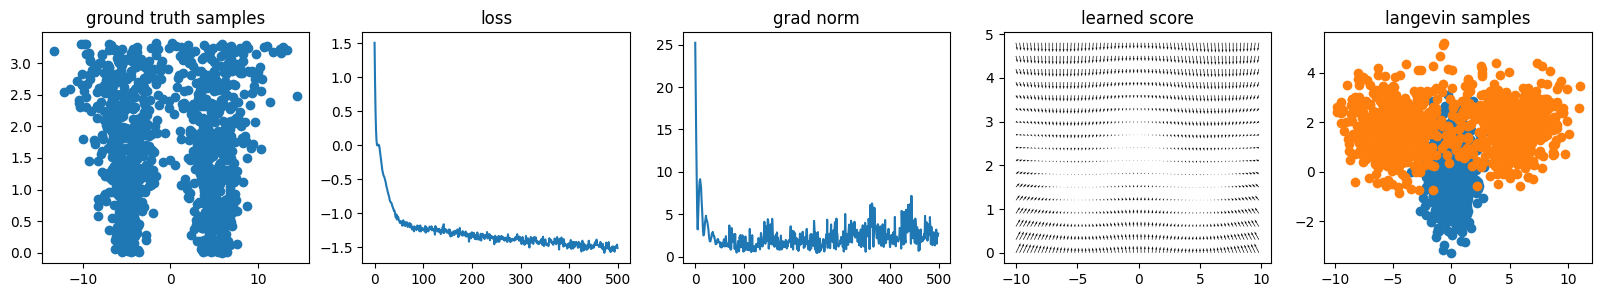

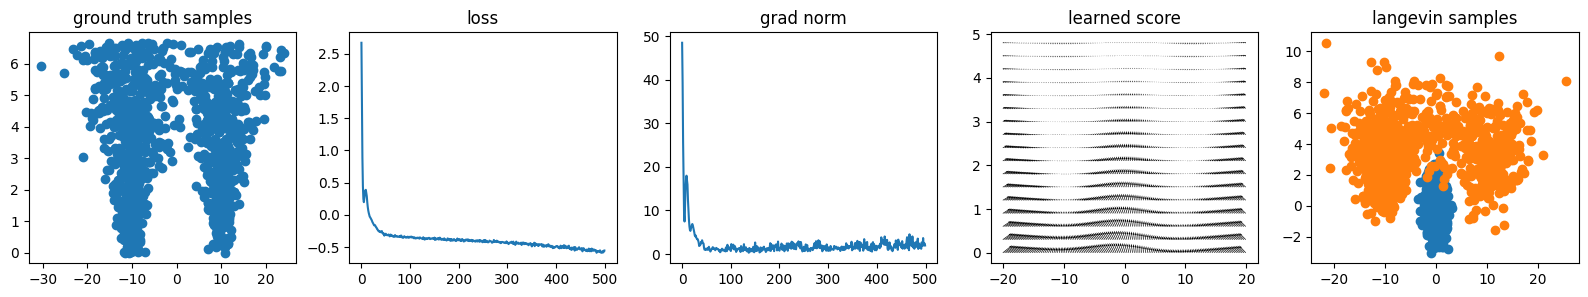

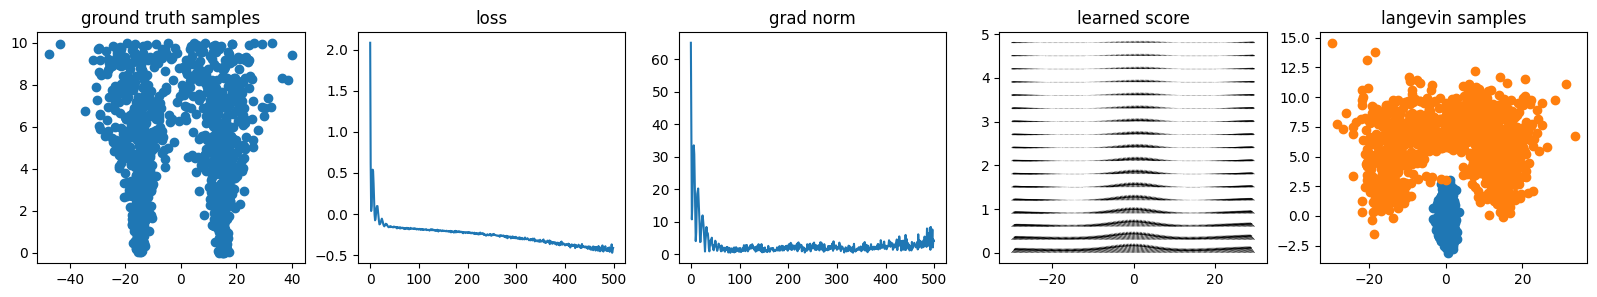

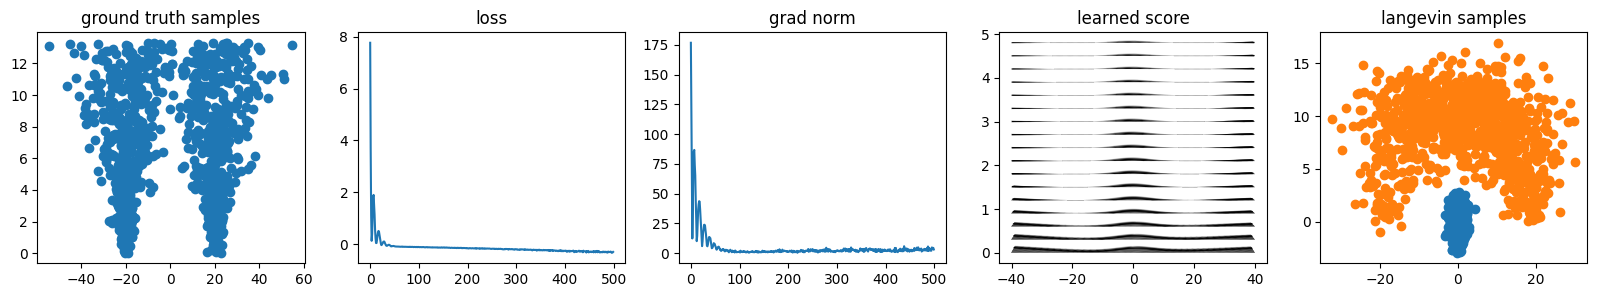

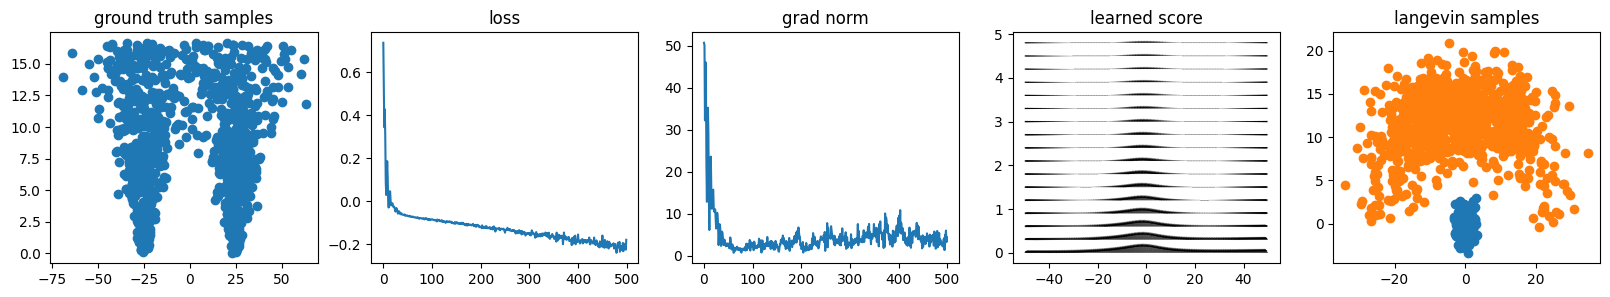

In [2]:
for mode_dist in range(10, 60, 10):
    fig, axs = plt.subplots(1, 5, figsize=(20, 3))
    distribution = BrownianDiffusionJoint(
        symmetric_gaussian_mixture_1d(mode_dist),
        max_temp = mode_dist / 3)
    x, y = distribution.sample((1000, )).numpy().T
    axs[0].scatter(x, y)
    axs[0].set_title('ground truth samples')

    model = torch.nn.Sequential(
        torch.nn.Linear(2, 128),
        torch.nn.Softplus(),
        torch.nn.Linear(128, 128),
        torch.nn.Softplus(),
        torch.nn.Linear(128, 2))
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
    score = Score2d(model, optimizer, distribution)

    loss, grad_norm = score.learn(
        n_samples_per_iter = 1000,
        n_iters = 500,
        keep_best = True,
        use_tqdm = False
    )
    axs[1].plot(loss)
    axs[1].set_title('loss')
    axs[2].plot(grad_norm)
    axs[2].set_title('grad norm')
    
    g, s = score.score_approx(-mode_dist, mode_dist, 0, 5, 0.3)
    g, s = g.numpy().T, s.numpy().T
    axs[3].quiver(g[0], g[1], s[0], s[1])
    axs[3].set_title('learned score')

    init_samples = standard_gaussian_2d().sample((1000, ))
    samples = score.sample_langevin(
        init_samples = init_samples,
        n_steps = 1000,
        epsilon = 0.1,
        use_tqdm = False
    )
    
    init_samples = init_samples.numpy().T
    samples = samples.numpy().T
    axs[4].scatter(init_samples[0], init_samples[1])
    axs[4].scatter(samples[0], samples[1])
    axs[4].set_title('langevin samples')

    plt.show()

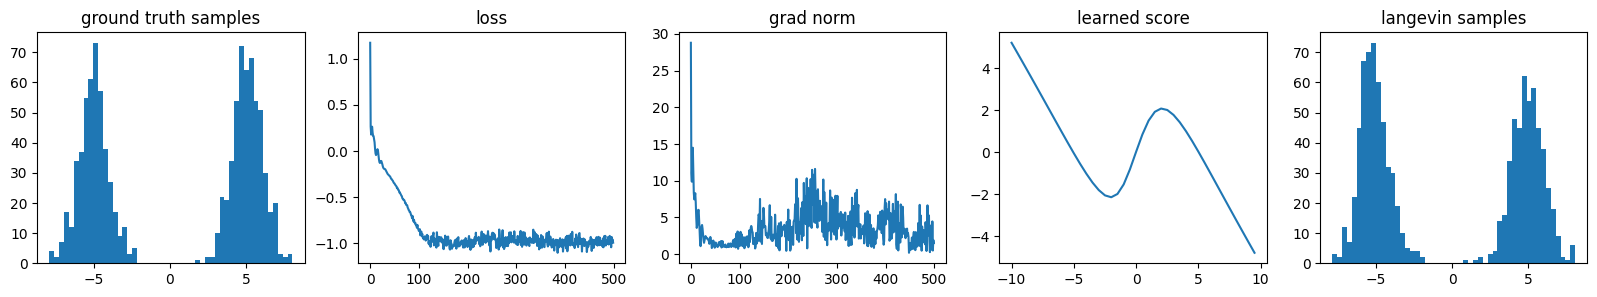

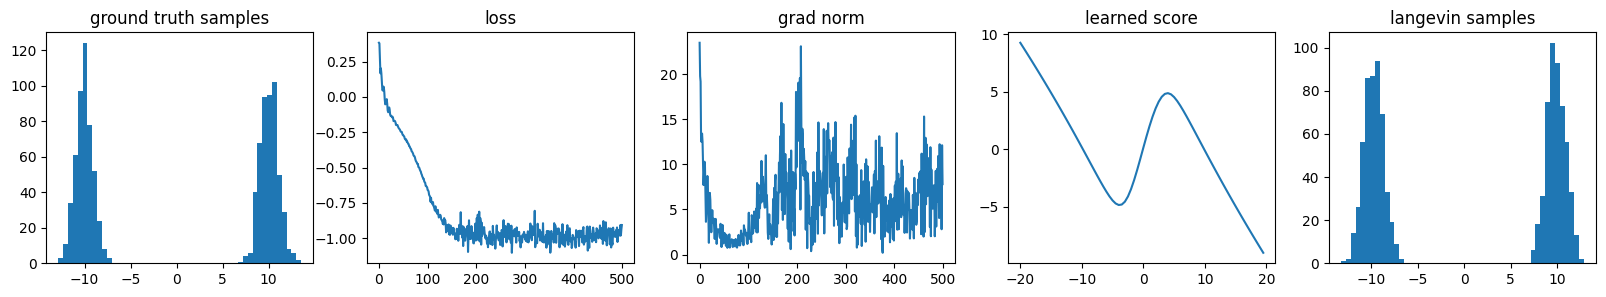

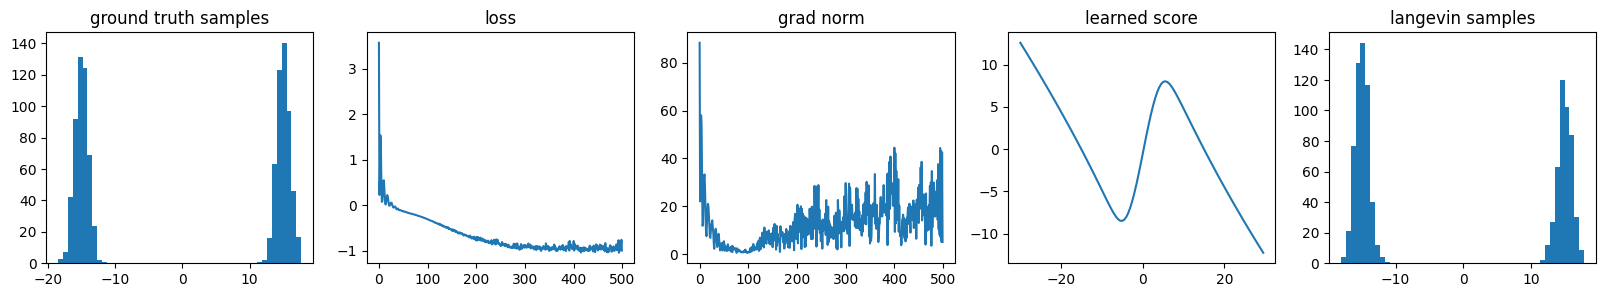

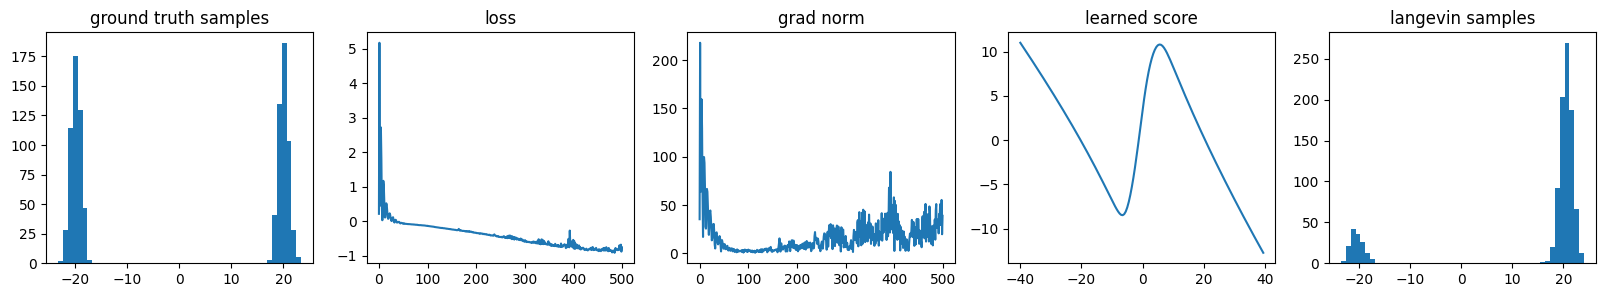

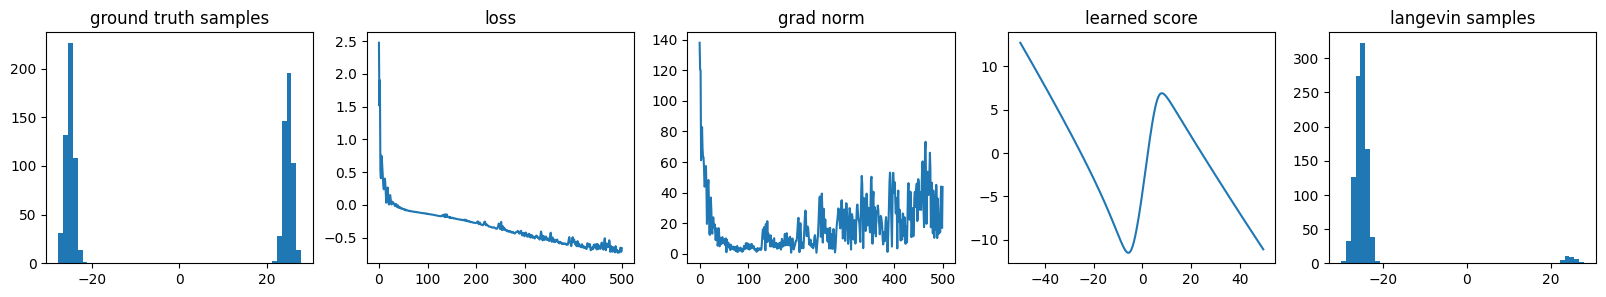

In [3]:
for mode_dist in range(10, 60, 10):
	fig, axs = plt.subplots(1, 5, figsize=(20, 3))
	distribution = symmetric_gaussian_mixture_1d(mode_dist)

	axs[0].hist(distribution.sample((1000, )).numpy(), bins=50)
	axs[0].set_title('ground truth samples')

	model = torch.nn.Sequential(
		torch.nn.Linear(1, 128),
		torch.nn.Softplus(),
		torch.nn.Linear(128, 128),
		torch.nn.Softplus(),
		torch.nn.Linear(128, 1))
	optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
	score = Score1d(model, optimizer, distribution)

	loss, grad_norm = score.learn(
		n_samples_per_iter = 1000,
		n_iters = 500,
		keep_best = True,
		use_tqdm = False
	)
	axs[1].plot(loss)
	axs[1].set_title('loss')
	axs[2].plot(grad_norm)
	axs[2].set_title('grad norm')


	g, s = score.score_approx(-mode_dist, mode_dist, 0.5)
	g, s = g.numpy().T, s.numpy().T
	axs[3].plot(g[0], s[0])
	axs[3].set_title('learned score')

	init_samples = standard_gaussian_1d().sample((1000, ))
	samples = score.sample_langevin(
		init_samples = init_samples,
		n_steps = 1000,
		epsilon = 0.1,
		use_tqdm = False
	)

	init_samples = init_samples.numpy().T
	samples = samples.numpy().T
	axs[4].hist(samples[0], bins=50)
	axs[4].set_title('langevin samples')

	plt.show()